In [1]:
import pandas as pd

# Load the dataset (Assuming the file is in the same directory)
# If it's in a subfolder, use 'data/application_train.csv'
try:
    df = pd.read_csv('../data/raw/home-credit-default-risk/application_train.csv')
    
    print("Dataset Loaded Successfully!")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    print("-" * 30)
    print("Here are the Headers (Column Names):")
    print(df.columns.tolist())

except FileNotFoundError:
    print("Error: 'application_train.csv' not found. Please check the file path.")

Dataset Loaded Successfully!
Total Rows: 307511
Total Columns: 122
------------------------------
Here are the Headers (Column Names):
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SO

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Check Class Imbalance
# ---------------------------------------------------------
target_counts = df['TARGET'].value_counts()
print("--- Class Distribution ---")
print(target_counts)
print(f"Default Rate: {(target_counts[1] / len(df)) * 100:.2f}%")
print("-" * 30)

# 2. Prepare Data for MVP Model (Numerical Only)
# ---------------------------------------------------------
# We select only numeric columns to avoid complex encoding for now.
# These map directly to your "What-If" Simulator sliders.
features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3' 
]

# Create X (Features) and y (Target)
X = df[features].copy()
y = df['TARGET']

# Quick Fix: XGBoost handles NaNs, but let's confirm data types are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 3. Train/Test Split (80% Train, 20% Test)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Baseline XGBoost
# ---------------------------------------------------------
print("Training Baseline XGBoost Model...")
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 5. Evaluate
# ---------------------------------------------------------
# We use probabilities (predict_proba) for AUC-ROC, not class labels (predict)
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"\nBaseline AUC-ROC Score: {auc_score:.4f}")
print("If this is above 0.70, your 'MVP' is already viable!")

--- Class Distribution ---
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default Rate: 8.07%
------------------------------
Training Baseline XGBoost Model...


d:\FYP\Augmented-Decision-Support-Model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:57:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Baseline AUC-ROC Score: 0.7485
If this is above 0.70, your 'MVP' is already viable!


d:\FYP\Augmented-Decision-Support-Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating Global Feature Importance...


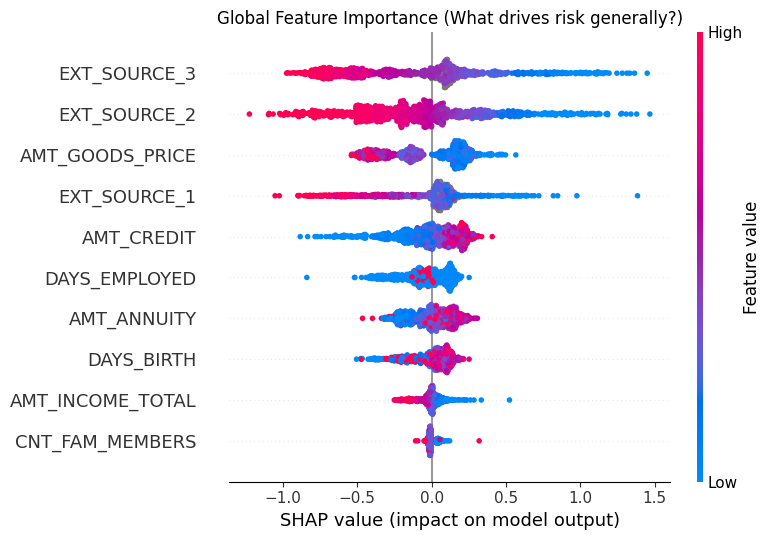


Analyzing Applicant #110
Model Predicted Risk: 0.5436 (Very High)


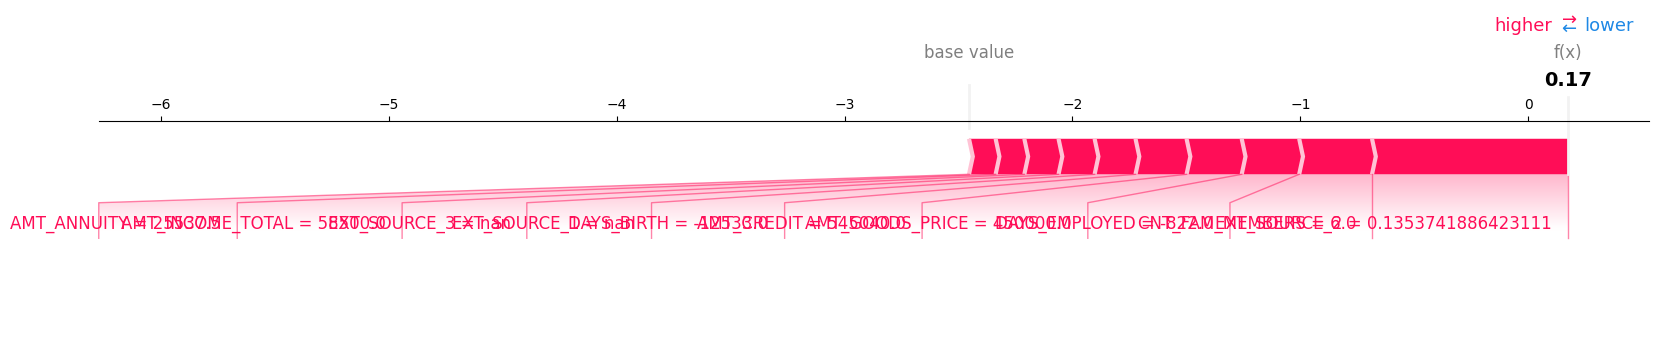

In [3]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# ---------------------------------------------------------
# We use the model you just trained
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP Values (Use a subset to save time!)
# ---------------------------------------------------------
# SHAP is computationally expensive. We'll use just 1000 rows from X_test.
# This is enough for a prototype and prevents your laptop from freezing.
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

# 3. GLOBAL Explanation (Summary Plot)
# ---------------------------------------------------------
print("Generating Global Feature Importance...")
plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("Global Feature Importance (What drives risk generally?)")
plt.tight_layout()
plt.show()

# 4. LOCAL Explanation (Loan Officer View)
# ---------------------------------------------------------
# Let's pick a high-risk applicant from our sample to analyze.
# We look for an index where the model predicted a high probability of default.
y_pred_prob_sample = model.predict_proba(X_test_sample)[:, 1]
high_risk_idx = y_pred_prob_sample.argmax()  # Find the riskiest person

print(f"\nAnalyzing Applicant #{high_risk_idx}")
print(f"Model Predicted Risk: {y_pred_prob_sample[high_risk_idx]:.4f} (Very High)")

# Force Plot (The classic 'Push/Pull' chart)
# Note: In a notebook, this is interactive. For a React app, we will send the raw values.
shap.initjs()
shap_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[high_risk_idx], 
    X_test_sample.iloc[high_risk_idx],
    matplotlib=True
)

In [4]:
# Save model and column names
model.save_model("model_mvp.json")

# We also need to save the list of features so the API knows the order
pd.Series(features).to_json("model_features.json")

print("Model and features saved successfully!")

Model and features saved successfully!


        DATASET OVERVIEW & METRICS       

1. Dataset Shape: 307511 Rows, 124 Columns

2. Data Types Distribution:
float64    67
int64      41
str        16
Name: count, dtype: int64

3. Top 10 Columns with Missing Values:
                          Total Missing  Percent %
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
COMMONAREA_MEDI                  214865  69.872297
NONLIVINGAPARTMENTS_AVG          213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_AVG             210199  68.354953
LIVINGAPARTMENTS_MODE            210199  68.354953

              VISUALIZATIONS             


C:\Users\hp\AppData\Local\Temp\ipykernel_9084\3074421718.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='TARGET', palette='Set2')


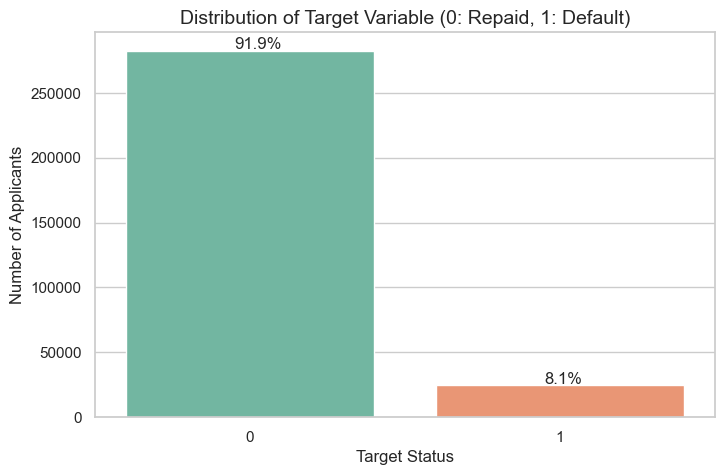

C:\Users\hp\AppData\Local\Temp\ipykernel_9084\3074421718.py:56: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['YEARS_EMPLOYED'].replace({365243/365: np.nan}, inplace=True)


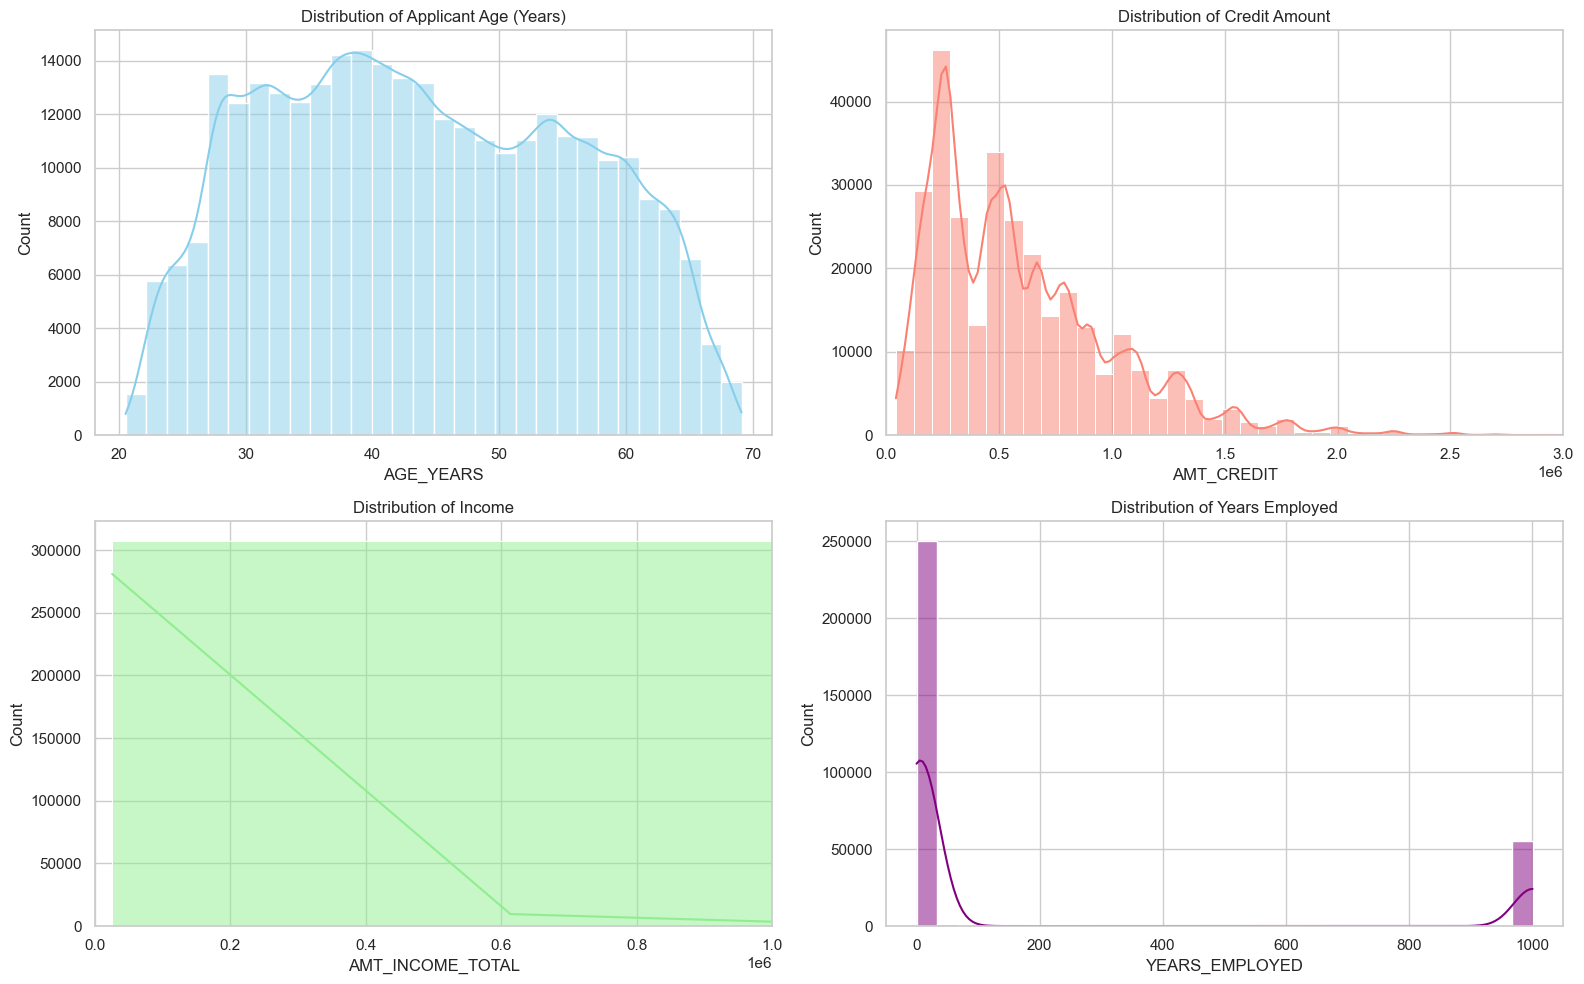


Plotting External Sources against Default Risk...


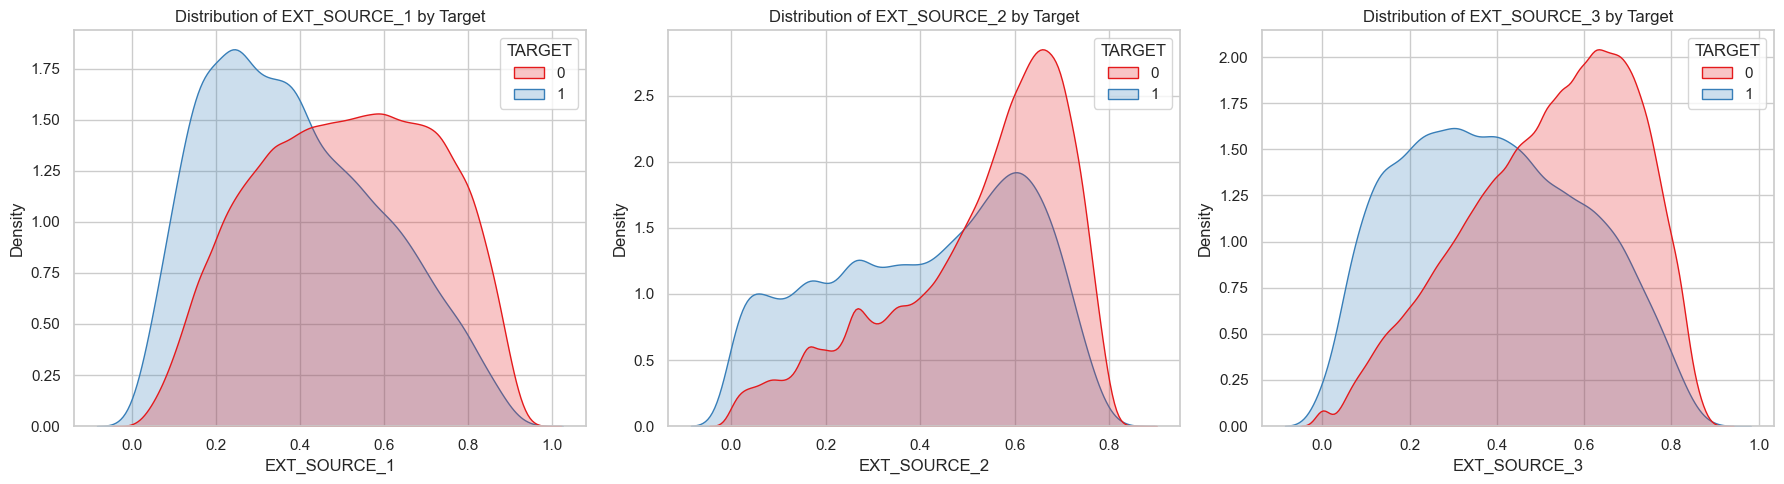


Generating Correlation Heatmap...


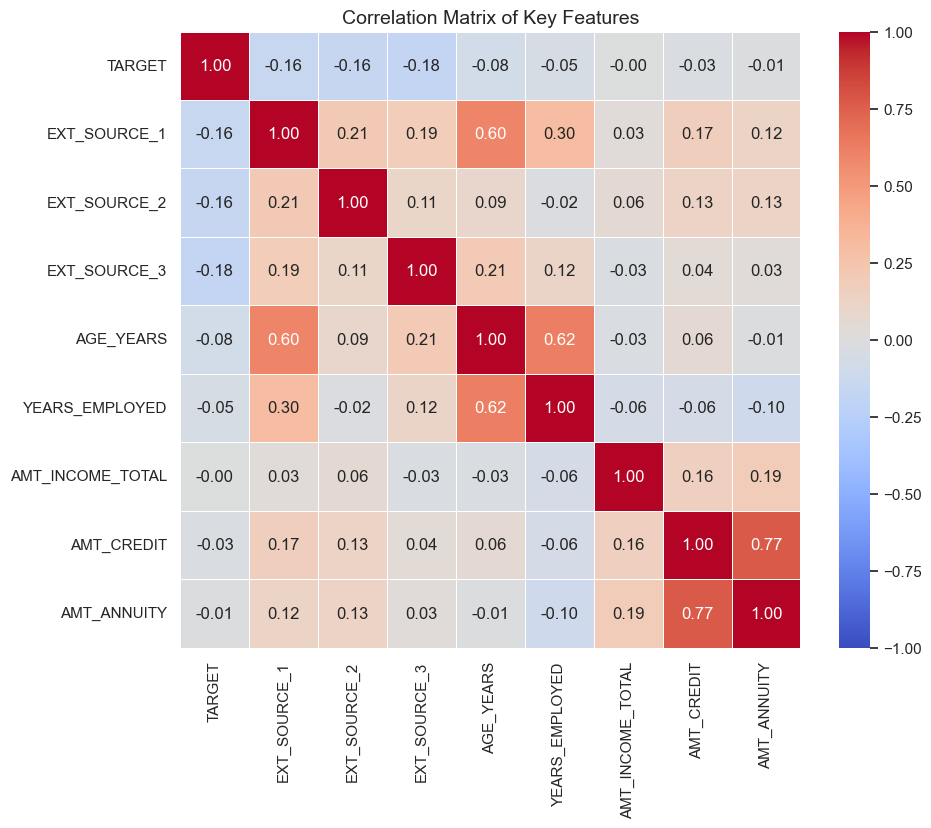

C:\Users\hp\AppData\Local\Temp\ipykernel_9084\3074421718.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='NAME_EDUCATION_TYPE', y='TARGET', palette='viridis')
C:\Users\hp\AppData\Local\Temp\ipykernel_9084\3074421718.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='CODE_GENDER', y='TARGET', palette='pastel')


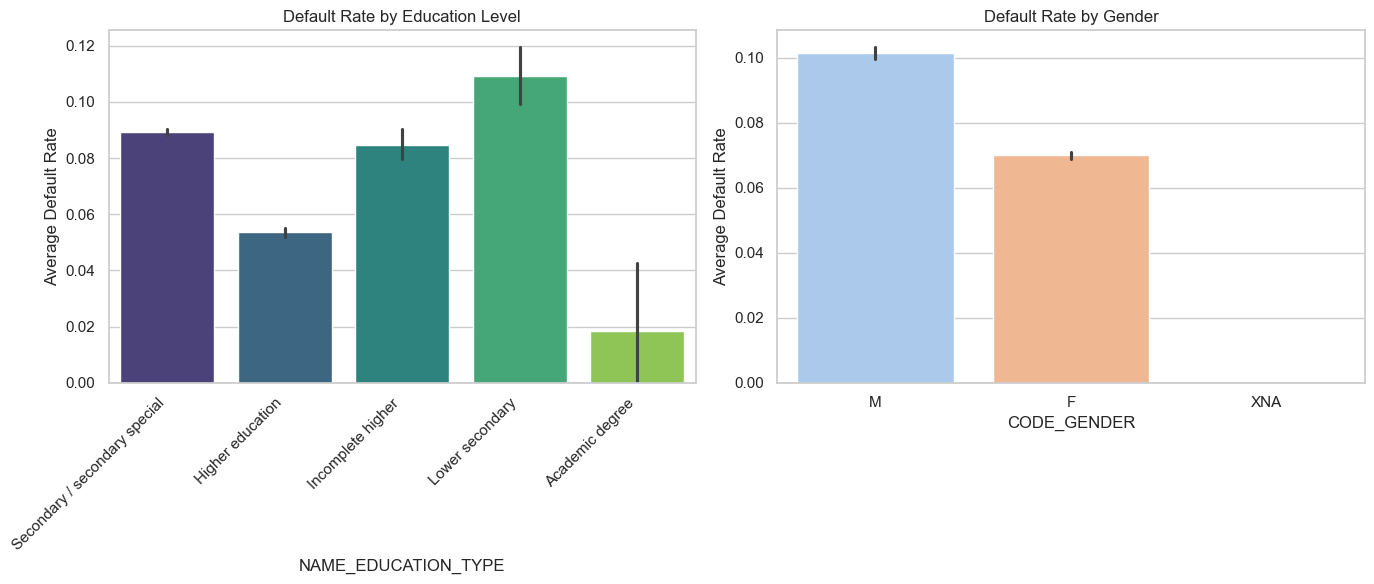

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the Data (Assuming you already have it loaded as 'df', if not, uncomment below)
# df = pd.read_csv('../data/raw/home-credit-default-risk/application_train.csv')

print("=========================================")
print("        DATASET OVERVIEW & METRICS       ")
print("=========================================")

# --- A. Basic Dimensions ---
print(f"\n1. Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")

# --- B. Data Types ---
print("\n2. Data Types Distribution:")
print(df.dtypes.value_counts())

# --- C. Missing Values Analysis ---
print("\n3. Top 10 Columns with Missing Values:")
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)
missing_df = pd.concat([missing_data, missing_percent], axis=1, keys=['Total Missing', 'Percent %'])
print(missing_df.head(10))


print("\n=========================================")
print("              VISUALIZATIONS             ")
print("=========================================")

# --- Visualization 1: Target Variable Distribution ---
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='TARGET', palette='Set2')
plt.title('Distribution of Target Variable (0: Repaid, 1: Default)', fontsize=14)
plt.ylabel('Number of Applicants')
plt.xlabel('Target Status')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), size=12)
plt.show()

# --- Visualization 2: Distribution of Key Numerical Features ---
# We convert DAYS_BIRTH to positive Years for readability
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
df['YEARS_EMPLOYED'] = abs(df['DAYS_EMPLOYED']) / 365
# Replace anomaly in DAYS_EMPLOYED (365243 means missing/pensioner)
df['YEARS_EMPLOYED'].replace({365243/365: np.nan}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df['AGE_YEARS'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Applicant Age (Years)')

sns.histplot(df['AMT_CREDIT'], bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Credit Amount')
axes[0, 1].set_xlim(0, 3000000) # Cap for better view

sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Income')
axes[1, 0].set_xlim(0, 1000000) # Cap outliers

sns.histplot(df['YEARS_EMPLOYED'].dropna(), bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribution of Years Employed')

plt.tight_layout()
plt.show()


# --- Visualization 3: External Sources (The strongest predictors) vs Target ---
print("\nPlotting External Sources against Default Risk...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=df, x=source, hue='TARGET', fill=True, common_norm=False, palette='Set1', ax=axes[i])
    axes[i].set_title(f'Distribution of {source} by Target')
plt.tight_layout()
plt.show()


# --- Visualization 4: Correlation Heatmap of Key Features ---
print("\nGenerating Correlation Heatmap...")
key_numeric_cols = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 
    'AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY'
]
corr_matrix = df[key_numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Key Features', fontsize=14)
plt.show()

# --- Visualization 5: Categorical Analysis (e.g., Education & Gender) ---
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='NAME_EDUCATION_TYPE', y='TARGET', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Default Rate by Education Level')
plt.ylabel('Average Default Rate')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='CODE_GENDER', y='TARGET', palette='pastel')
plt.title('Default Rate by Gender')
plt.ylabel('Average Default Rate')

plt.tight_layout()
plt.show()